# Faker

In [2]:
from faker import Faker
import random
from datetime import datetime

fake = Faker('es_MX')

def generar_datos_ejemplo(n=100):
    datos = []
    for _ in range(n):
        registro = {
            "nombre": fake.name(),
            "edad": random.randint(18, 99),
            "ciudad": fake.city(),
            "fecha_reporte": fake.date_between(start_date='-2y', end_date='today').strftime('%Y-%m-%d'),
            "categoria": random.choice(['Seguridad', 'Salud', 'Infraestructura', 'Servicios']),
            "genero": random.choice(['Masculino', 'Femenino', 'Otro']),
            "descripcion": fake.sentence(nb_words=10),
            "comentario": fake.paragraph(nb_sentences=3),
            "gravedad": random.randint(1, 5),
            "latitud": float(fake.latitude()),
            "longitud": float(fake.longitude())

        }
        datos.append(registro)
    return datos

mis_datos = generar_datos_ejemplo(5000)
print(f"generados {len(mis_datos)} registros de ejemplo:")

generados 5000 registros de ejemplo:


# MongoDB

In [3]:
from pymongo import MongoClient

def insertar_datos_mongodb(datos):
    try:
        cliente = MongoClient('mongodb://localhost:27017/')
        db = cliente['Actividad2']
        coleccion = db['reportes']

        resultado = coleccion.insert_many(datos)
        print(f"Registros insertados")
    except Exception as e:
        print(f"Error: {e}")
    finally:
        cliente.close()
        print("Conexión cerrada")
insertar_datos_mongodb(mis_datos)

Registros insertados
Conexión cerrada


# Pandas


In [4]:
from pymongo import MongoClient
import pandas as pd

def Leer_datos_mongodb():
    try:
        cliente = MongoClient('mongodb://localhost:27017/')
        db = cliente['Actividad2']
        coleccion = db['reportes']

        datos = list(coleccion.find())

        df = pd.DataFrame(datos)

        print(df.head())
        print("Datos leídos correctamente")

        return df
    
    except Exception as e:
        print(f"Error: {e}")
    finally:
        cliente.close()
        print("Conexión cerrada")
dataframe_mongodb = Leer_datos_mongodb()
display(dataframe_mongodb)

                        _id                             nombre  edad  \
0  69c69046b94a91c4de66c0a8                Pablo Elias Salcido    96   
1  69c69046b94a91c4de66c0a9         Pascual Cristobal Elizondo    71   
2  69c69046b94a91c4de66c0aa   Salvador Felix Mercado Villareal    26   
3  69c69046b94a91c4de66c0ab             Srita. Conchita Macías    45   
4  69c69046b94a91c4de66c0ac  Guadalupe Marisela Chacón Serrano    63   

                  ciudad fecha_reporte  categoria    genero  \
0           Nueva Egipto    2024-10-17  Seguridad  Femenino   
1     San Inés los bajos    2025-04-18      Salud      Otro   
2  San Octavio los bajos    2025-05-23      Salud      Otro   
3          Nueva Namibia    2025-12-17  Servicios  Femenino   
4         Vieja Kiribati    2025-05-09      Salud      Otro   

                                         descripcion  \
0       Miedo concepto pedro líder relaciones salud.   
1  Premio será partidos formación palabra polític...   
2  Acto obstante cul

,_id,nombre,edad,ciudad,fecha_reporte,categoria,genero,descripcion,comentario,gravedad,latitud,longitud
0,69c69046b94a91c4de66c0a8,Pablo Elias Salcido,96,Nueva Egipto,2024-10-17,Seguridad,Femenino,Miedo concepto pedro líder relaciones salud.,Real son nuestro bastante estas llegar muchas ...,1,60.429527,45.177010
1,69c69046b94a91c4de66c0a9,Pascual Cristobal Elizondo,71,San Inés los bajos,2025-04-18,Salud,Otro,Premio será partidos formación palabra polític...,Color cuyo país primeros. Tenido sangre trabaj...,3,-59.174112,-49.058415
2,69c69046b94a91c4de66c0aa,Salvador Felix Mercado Villareal,26,San Octavio los bajos,2025-05-23,Salud,Otro,Acto obstante cultura calidad miembros durante...,Madre hora resultados nueva viejo libros. El v...,2,-52.156115,-28.184589
3,69c69046b94a91c4de66c0ab,Srita. Conchita Macías,45,Nueva Namibia,2025-12-17,Servicios,Femenino,Luz e plazo afirmó administración gran y varias.,Aquel nacional fuego productos. Interior minut...,2,20.169879,-123.307143
4,69c69046b94a91c4de66c0ac,Guadalupe Marisela Chacón Serrano,63,Vieja Kiribati,2025-05-09,Salud,Otro,Tiene características público consumo fútbol v...,Éxito sean políticos cierto. Aun participación...,3,-1.441142,-77.973170
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,69c69046b94a91c4de66d42b,Sr. José María Almonte,47,San Teresa de la Montaña,2024-09-30,Infraestructura,Femenino,Hablar nos caso precisamente capacidad mayores.,Salida hacia frente grande. J real último sept...,1,-89.761248,141.134740
4996,69c69046b94a91c4de66d42c,Aurelio Hernán Parra,64,San Alejandro los bajos,2026-03-07,Seguridad,Masculino,Padre hubiera hacía problemas ver título dicho...,Aquí importancia tampoco habla. Pasa encuentra...,4,41.848102,32.958329
4997,69c69046b94a91c4de66d42d,Lic. Ángela Barela,20,Nueva Pakistán,2024-08-13,Seguridad,Masculino,Espera seguro grupo este alguien servicio últi...,Barcelona la manos hacerlo buena pasado. Va po...,4,-18.266105,-62.057604
4998,69c69046b94a91c4de66d42e,Oswaldo Ornelas,73,Vieja Armenia,2024-08-22,Infraestructura,Masculino,Evitar será quiere viene pues tenido juez puer...,Noviembre nombre mercado guerra. Humanos algun...,5,70.365927,-5.556339


# Analisis Datos

In [5]:
import numpy as np

columnas_numericas = ['edad', 'gravedad', 'latitud', 'longitud']

media = dataframe_mongodb[columnas_numericas].mean()

mediana = dataframe_mongodb[columnas_numericas].median()

moda = dataframe_mongodb[columnas_numericas].mode().iloc[0]

resumen_numerico = pd.DataFrame({
    'Media': media,
    'Mediana': mediana,
    'Moda': moda
})

categoricas = ['ciudad', 'categoria', 'genero']

moda_categoricas = dataframe_mongodb[categoricas].mode().iloc[0]

print("Moda de variables categóricas:")
print(moda_categoricas)

for col in categoricas:
    print(f"\nFrecuencia de {col}:")
    print(dataframe_mongodb[col].value_counts())

print(resumen_numerico)

print("\nResumen general:")
print(dataframe_mongodb.describe(include='all'))

Moda de variables categóricas:
ciudad       Vieja Namibia
categoria            Salud
genero           Masculino
Name: 0, dtype: str

Frecuencia de ciudad:
ciudad
Vieja Namibia                        15
Vieja Bélgica                        13
Nueva Eslovenia                      13
Nueva Tailandia                      13
Nueva República Unida de Tanzanía    13
                                     ..
San Eugenio los altos                 1
San Indira los bajos                  1
San Hernán los altos                  1
San Delia los altos                   1
San Marcos los bajos                  1
Name: count, Length: 1336, dtype: int64

Frecuencia de categoria:
categoria
Salud              1265
Servicios          1257
Seguridad          1250
Infraestructura    1228
Name: count, dtype: int64

Frecuencia de genero:
genero
Masculino    1676
Femenino     1673
Otro         1651
Name: count, dtype: int64
              Media    Mediana        Moda
edad      58.397200  58.000000   32.000000
grav

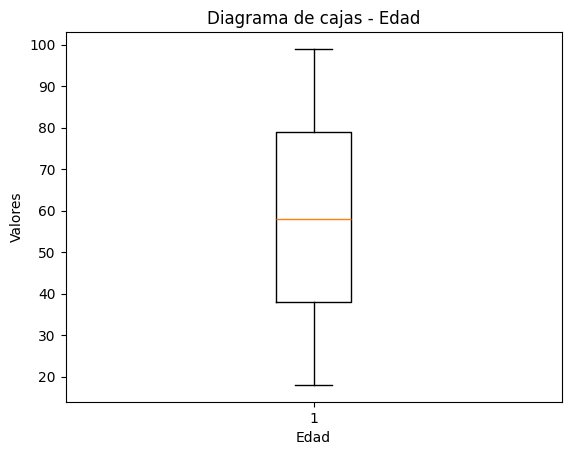

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(dataframe_mongodb['edad'])
plt.title("Diagrama de cajas - Edad")
plt.xlabel("Edad")
plt.ylabel("Valores")

plt.show()

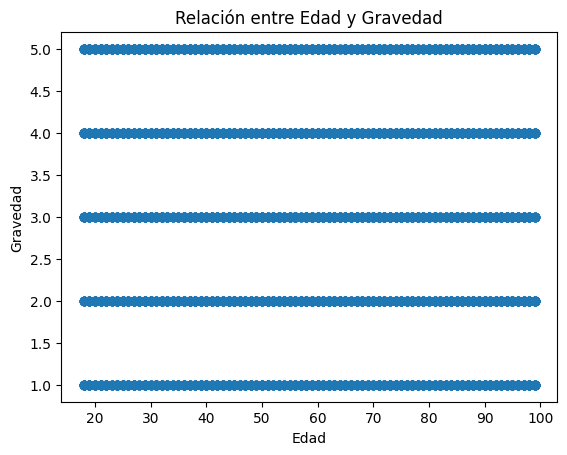

In [ ]:
plt.figure()
plt.scatter(dataframe_mongodb['edad'], dataframe_mongodb['gravedad'])

plt.title("Relación entre Edad y Gravedad")
plt.xlabel("Edad")
plt.ylabel("Gravedad")

plt.show()